# Flight Delay Project — Phase 3: Data Analysis

**Course:** COMP4381 Data Science and Analytics — Spring 2026  
**Instructor:** Ahmed Sabbah  

**Team:** Andrew Odeh - 1222212 , Omar shujaieh -  

**Group:** Predictive Minds

This notebook is the **Phase 3** deliverable. It covers the dataset description, the data sources, cleaning, preprocessing, summarization, visualizations and the interpretation of each result. Every step is explained in Markdown so the notebook is self-contained and no separate report is required.

> **Unit of analysis:** one row = **one airport on one day** (an *airport-day* record).


## 1. Project scope and data design

We study **arrival punctuality at five European airports**, one per country:

| Country | Airport | ICAO |
|---|---|---|
| Ireland | Dublin | `EIDW` |
| Denmark | Copenhagen (Kastrup) | `EKCH` |
| Portugal | Lisbon (Humberto Delgado) | `LPPT` |
| Belgium | Brussels (Zaventem) | `EBBR` |
| Austria | Vienna (Schwechat) | `LOWW` |

**Why airport-day records?** Each airport produces one record per calendar day, so 5 airports × ~365 days × 3 years gives several thousand rows — comfortably above the 1,000-row requirement — while keeping the analysis simple and reproducible.

**Prediction target (created here, modelled in Phase 4):** a punctuality class `delay_level` (`Low` / `Medium` / `High`) derived from ATFM arrival delay per arrival.


## 2. Data sources

All data is read directly from permanent public URLs, so this notebook runs end-to-end with **no manual downloads** (the reproducibility requirement).

1. **EUROCONTROL — Airport Arrival ATFM Delay** (`apt_dly`, one compressed CSV per year). Daily minutes of Air Traffic Flow Management (ATFM) arrival delay per airport, broken down by cause (weather, capacity, staffing, …), plus counts of delayed arrivals. → our **delay / target** source.  
   <https://ansperformance.eu/reference/dataset/airport-arrival-atfm-delay/>
2. **EUROCONTROL — Airport Traffic** (`airport_traffic`, one CSV per year). Daily IFR arrivals, departures and total movements per airport. → our **traffic** source.  
   <https://ansperformance.eu/reference/dataset/airport-traffic/>
3. **OurAirports — airport metadata** (one global CSV). Airport type, latitude, longitude, elevation, region, municipality and scheduled-service flag. → **enrichment** so we reach 15+ meaningful features.  
   <https://ourairports.com/data/>

The two EUROCONTROL files share the keys `FLT_DATE` and `APT_ICAO`, so we merge them on **(airport, date)**; OurAirports is merged on the **ICAO code**.


### 3. Setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io, requests

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### 4. Configuration

The airports and years live in one place so the whole analysis is easy to adjust.


In [49]:
# One airport per country (ICAO codes)
AIRPORTS = ["EIDW", "EKCH", "LPPT", "EBBR", "LOWW"]   # Dublin, Copenhagen, Lisbon, Brussels, Vienna
YEARS    = [2023, 2024, 2025]

# Permanent public data URLs
DELAY_URL         = "https://www.eurocontrol.int/performance/data/download/csv/apt_dly_{year}.csv.bz2"
TRAFFIC_URL       = "https://www.eurocontrol.int/performance/data/download/csv/airport_traffic_{year}.csv"
AIRPORTS_META_URL = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"

In [50]:
import io, bz2, requests
HEADERS = {"User-Agent": "Mozilla/5.0"}

def load_csv(url, **kwargs):
    kwargs.pop("compression", None)
    kwargs.setdefault("encoding", "latin-1")   # EUROCONTROL files are Latin-1
    r = requests.get(url, headers=HEADERS, timeout=180)
    r.raise_for_status()
    data = r.content
    if url.endswith(".bz2"):
        try:
            data = bz2.decompress(data)
        except OSError:
            pass
    return pd.read_csv(io.BytesIO(data), **kwargs)

# load delay data
delay_parts = [load_csv(DELAY_URL.format(year=y)) for y in YEARS]
delay_raw = pd.concat(delay_parts, ignore_index=True)
print("Delay raw shape:", delay_raw.shape)
delay_raw.head()

Delay raw shape: (302010, 28)


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_ARR_1,DLY_APT_ARR_1,DLY_APT_ARR_A_1,DLY_APT_ARR_C_1,DLY_APT_ARR_D_1,DLY_APT_ARR_E_1,DLY_APT_ARR_G_1,DLY_APT_ARR_I_1,DLY_APT_ARR_M_1,DLY_APT_ARR_N_1,DLY_APT_ARR_O_1,DLY_APT_ARR_P_1,DLY_APT_ARR_R_1,DLY_APT_ARR_S_1,DLY_APT_ARR_T_1,DLY_APT_ARR_V_1,DLY_APT_ARR_W_1,DLY_APT_ARR_NA_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,ATFM_VERSION
0,2023,1,JAN,2023-01-01T00:00:00Z,EGPH,Edinburgh,United Kingdom,105,77,0,0,0,0,0,0,0,0,0,0,0,0,77,0,0,0,4,2,v2
1,2023,1,JAN,2023-01-02T00:00:00Z,LIPZ,Venice,Italy,119,104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,104,0,9,2,v2
2,2023,1,JAN,2023-01-02T00:00:00Z,LPPR,Porto,Portugal,144,309,0,0,0,0,0,0,0,0,0,309,0,0,0,0,0,0,21,9,v2
3,2023,1,JAN,2023-01-02T00:00:00Z,LPPT,Lisbon,Portugal,325,2826,0,0,0,0,2826,0,0,0,0,0,0,0,0,0,0,0,123,73,v2
4,2023,1,JAN,2023-01-03T00:00:00Z,EDDP,Leipzig-Halle,Germany,102,116,0,0,0,0,0,0,0,0,0,0,0,0,0,0,116,0,16,1,v2


## 5. Load the raw data

We download each yearly file and stack the years together with `pd.concat`.

> If any table loads as a **single merged column**, the file is using `;` instead of `,` — add `sep=";"` to the matching `load_csv` call.


In [51]:
# Delay data (one compressed CSV per year)
delay_parts = []
for y in YEARS:
    delay_parts.append(load_csv(DELAY_URL.format(year=y), compression="bz2"))
delay_raw = pd.concat(delay_parts, ignore_index=True)
print("Delay raw shape:", delay_raw.shape)
delay_raw.head()

Delay raw shape: (302010, 28)


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_ARR_1,DLY_APT_ARR_1,DLY_APT_ARR_A_1,DLY_APT_ARR_C_1,DLY_APT_ARR_D_1,DLY_APT_ARR_E_1,DLY_APT_ARR_G_1,DLY_APT_ARR_I_1,DLY_APT_ARR_M_1,DLY_APT_ARR_N_1,DLY_APT_ARR_O_1,DLY_APT_ARR_P_1,DLY_APT_ARR_R_1,DLY_APT_ARR_S_1,DLY_APT_ARR_T_1,DLY_APT_ARR_V_1,DLY_APT_ARR_W_1,DLY_APT_ARR_NA_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,ATFM_VERSION
0,2023,1,JAN,2023-01-01T00:00:00Z,EGPH,Edinburgh,United Kingdom,105,77,0,0,0,0,0,0,0,0,0,0,0,0,77,0,0,0,4,2,v2
1,2023,1,JAN,2023-01-02T00:00:00Z,LIPZ,Venice,Italy,119,104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,104,0,9,2,v2
2,2023,1,JAN,2023-01-02T00:00:00Z,LPPR,Porto,Portugal,144,309,0,0,0,0,0,0,0,0,0,309,0,0,0,0,0,0,21,9,v2
3,2023,1,JAN,2023-01-02T00:00:00Z,LPPT,Lisbon,Portugal,325,2826,0,0,0,0,2826,0,0,0,0,0,0,0,0,0,0,0,123,73,v2
4,2023,1,JAN,2023-01-03T00:00:00Z,EDDP,Leipzig-Halle,Germany,102,116,0,0,0,0,0,0,0,0,0,0,0,0,0,0,116,0,16,1,v2


In [52]:
# Traffic data (one CSV per year)
traffic_parts = []
for y in YEARS:
    traffic_parts.append(load_csv(TRAFFIC_URL.format(year=y)))
traffic_raw = pd.concat(traffic_parts, ignore_index=True)
print("Traffic raw shape:", traffic_raw.shape)
traffic_raw.head()

Traffic raw shape: (345621, 13)


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2023,1,JAN,2023-01-01,LATI,Tirana,Albania,41,44,85,NaN,NaN,NaN
1,2023,1,JAN,2023-01-01,UDYZ,Yerevan,Armenia,49,50,99,NaN,NaN,NaN
2,2023,1,JAN,2023-01-01,LOWG,Graz,Austria,7,12,19,NaN,NaN,NaN
3,2023,1,JAN,2023-01-01,LOWI,Innsbruck,Austria,41,44,85,NaN,NaN,NaN
4,2023,1,JAN,2023-01-01,LOWK,Klagenfurt,Austria,5,6,11,NaN,NaN,NaN


In [53]:
# Airport metadata (one global file)
airports_meta = load_csv(AIRPORTS_META_URL)
print("Airport metadata shape:", airports_meta.shape)
airports_meta.head()

Airport metadata shape: (85531, 19)


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


### 5.1 Filter to our 5 airports

The EUROCONTROL files contain the whole European network. We keep only our five airports first, which also makes every later step fast.


In [54]:
delay   = delay_raw[delay_raw["APT_ICAO"].isin(AIRPORTS)].copy()
traffic = traffic_raw[traffic_raw["APT_ICAO"].isin(AIRPORTS)].copy()
print("Delay (5 airports):  ", delay.shape)
print("Traffic (5 airports):", traffic.shape)

Delay (5 airports):   (5477, 28)
Traffic (5 airports): (5477, 13)


## 6. Cleaning

We follow the cleaning checklist from the course: **(1) data types, (2) inconsistency, (3) duplicates, (4) missing values, (5) outliers.**


### 6.1 Validate data types

We inspect the columns and then convert `FLT_DATE` to a real datetime. The two EUROCONTROL files use slightly different date formats (the delay file uses ISO `2025-01-02T00:00:00Z`, the traffic file uses `01-Jan-2025`), so we parse both safely and reduce them to a day-level date that we can merge on.


In [55]:
delay.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5477 entries, 3 to 301987
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   YEAR              5477 non-null   int64 
 1   MONTH_NUM         5477 non-null   int64 
 2   MONTH_MON         5477 non-null   object
 3   FLT_DATE          5477 non-null   object
 4   APT_ICAO          5477 non-null   object
 5   APT_NAME          5477 non-null   object
 6   STATE_NAME        5477 non-null   object
 7   FLT_ARR_1         5477 non-null   int64 
 8   DLY_APT_ARR_1     5477 non-null   int64 
 9   DLY_APT_ARR_A_1   5477 non-null   int64 
 10  DLY_APT_ARR_C_1   5477 non-null   int64 
 11  DLY_APT_ARR_D_1   5477 non-null   int64 
 12  DLY_APT_ARR_E_1   5477 non-null   int64 
 13  DLY_APT_ARR_G_1   5477 non-null   int64 
 14  DLY_APT_ARR_I_1   5477 non-null   int64 
 15  DLY_APT_ARR_M_1   5477 non-null   int64 
 16  DLY_APT_ARR_N_1   5477 non-null   int64 
 17  DLY_APT_ARR_O_1  

In [56]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5477 entries, 7 to 345538
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   YEAR           5477 non-null   int64  
 1   MONTH_NUM      5477 non-null   int64  
 2   MONTH_MON      5477 non-null   object 
 3   FLT_DATE       5477 non-null   object 
 4   APT_ICAO       5477 non-null   object 
 5   APT_NAME       5477 non-null   object 
 6   STATE_NAME     5477 non-null   object 
 7   FLT_DEP_1      5477 non-null   int64  
 8   FLT_ARR_1      5477 non-null   int64  
 9   FLT_TOT_1      5477 non-null   int64  
 10  FLT_DEP_IFR_2  5477 non-null   float64
 11  FLT_ARR_IFR_2  5477 non-null   float64
 12  FLT_TOT_IFR_2  5477 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 599.0+ KB


In [57]:
def to_date(series):
    # Parse mixed date formats safely, then drop the time/timezone -> day-level date.
    parsed = pd.to_datetime(series, utc=True, errors="coerce")
    return parsed.dt.tz_convert(None).dt.normalize()

delay["date"]   = to_date(delay["FLT_DATE"])
traffic["date"] = to_date(traffic["FLT_DATE"])

print("Unparsed dates in delay:  ", delay["date"].isna().sum())
print("Unparsed dates in traffic:", traffic["date"].isna().sum())

Unparsed dates in delay:   0
Unparsed dates in traffic: 0


### 6.2 Build the analytical table (merge)

We keep only the columns we need from each source, then merge.

* From **traffic**: airport name, country, and the daily flight counts.
* From **delay**: total ATFM arrival delay, the number of delayed arrivals, and two weather-related delay causes (`W` = weather, `D` = de-icing). Weather features are *strongly encouraged* by the brief, and here they come from the same reproducible file.

We merge traffic and delay on **(airport, date)** with an inner join (we keep only airport-days present in both), then attach the airport metadata on the **ICAO code**.


In [58]:
delay_cols = ["APT_ICAO", "date", "DLY_APT_ARR_1",
              "FLT_ARR_1_DLY", "FLT_ARR_1_DLY_15",
              "DLY_APT_ARR_W_1", "DLY_APT_ARR_D_1"]
delay_small = delay[delay_cols].copy()

traffic_cols = ["APT_ICAO", "date", "APT_NAME", "STATE_NAME",
                "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1"]
traffic_small = traffic[traffic_cols].copy()

df = pd.merge(traffic_small, delay_small, on=["APT_ICAO", "date"], how="inner")
print("Merged (traffic + delay):", df.shape)
df.head()

Merged (traffic + delay): (5477, 12)


,APT_ICAO,date,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,DLY_APT_ARR_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,DLY_APT_ARR_W_1,DLY_APT_ARR_D_1
0,LOWW,2023-01-01,Vienna,Austria,252,221,473,0,0,0,0,0
1,EBBR,2023-01-01,Brussels,Belgium,183,172,355,0,0,0,0,0
2,EKCH,2023-01-01,Copenhagen - Kastrup,Denmark,246,238,484,0,0,0,0,0
3,EIDW,2023-01-01,Dublin,Ireland,292,283,575,0,0,0,0,0
4,LPPT,2023-01-01,Lisbon,Portugal,299,290,589,1012,70,25,852,0


In [59]:
meta_cols = ["ident", "type", "latitude_deg", "longitude_deg",
             "elevation_ft", "iso_country", "iso_region",
             "municipality", "scheduled_service"]
df = pd.merge(df, airports_meta[meta_cols], left_on="APT_ICAO", right_on="ident", how="left")
df = df.drop(columns=["ident"])
print("After metadata merge:", df.shape)
df.head()

After metadata merge: (5477, 20)


,APT_ICAO,date,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,DLY_APT_ARR_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,DLY_APT_ARR_W_1,DLY_APT_ARR_D_1,type,latitude_deg,longitude_deg,elevation_ft,iso_country,iso_region,municipality,scheduled_service
0,LOWW,2023-01-01,Vienna,Austria,252,221,473,0,0,0,0,0,large_airport,48.110298,16.569700,600.0,AT,AT-9,Vienna,yes
1,EBBR,2023-01-01,Brussels,Belgium,183,172,355,0,0,0,0,0,large_airport,50.901402,4.484440,175.0,BE,BE-VBR,Zaventem,yes
2,EKCH,2023-01-01,Copenhagen - Kastrup,Denmark,246,238,484,0,0,0,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes
3,EIDW,2023-01-01,Dublin,Ireland,292,283,575,0,0,0,0,0,large_airport,53.428713,-6.262121,242.0,IE,IE-D,Dublin,yes
4,LPPT,2023-01-01,Lisbon,Portugal,299,290,589,1012,70,25,852,0,large_airport,38.781300,-9.135920,374.0,PT,PT-11,Lisbon,yes


### 6.3 Inconsistency

We use `value_counts()` (the approach from the course) to confirm that the categorical keys are written consistently across the merged years.


In [60]:
df["STATE_NAME"].value_counts()

,count
STATE_NAME,
Austria,1096
Belgium,1096
Denmark,1096
Portugal,1096
Ireland,1093


In [61]:
df["APT_NAME"].value_counts()

,count
APT_NAME,
Vienna,1096
Brussels,1096
Copenhagen - Kastrup,1096
Lisbon,1096
Dublin,1093


*Interpretation:* each country name and airport name should appear in exactly one spelling. If you see a duplicate spelling (for example two versions of the same country), fix it with `df["STATE_NAME"] = df["STATE_NAME"].replace({...})`, exactly like the Payment-Method / Country example in the course notebook.


### 6.4 Duplicates

Duplicate rows would over-count some airport-days, so we check and drop them.


In [62]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 0
Shape after dropping duplicates: (5477, 20)


### 6.5 Missing values

We check the missing counts, then handle each column based on what the missing value *means*:

* **Delay columns** (`DLY_APT_ARR_1`, delayed-arrival counts, weather causes): a missing value means *no ATFM delay was recorded that day*, so the correct fill is **0**.
* **Traffic columns** (`FLT_ARR_1`, `FLT_DEP_1`, `FLT_TOT_1`): these are essential. A day with no arrivals cannot give a delay-per-arrival, so we **drop** those rows.
* **Metadata**: all five airports matched, so this should be complete; we drop any row that is somehow missing it.


In [63]:
df.isna().sum()

,0
APT_ICAO,0
date,0
APT_NAME,0
STATE_NAME,0
FLT_DEP_1,0
FLT_ARR_1,0
FLT_TOT_1,0
DLY_APT_ARR_1,0
FLT_ARR_1_DLY,0
FLT_ARR_1_DLY_15,0


In [64]:
delay_fill_cols = ["DLY_APT_ARR_1", "FLT_ARR_1_DLY", "FLT_ARR_1_DLY_15",
                   "DLY_APT_ARR_W_1", "DLY_APT_ARR_D_1"]
df[delay_fill_cols] = df[delay_fill_cols].fillna(0)

df = df[df["FLT_ARR_1"].notna() & (df["FLT_ARR_1"] > 0)]
df = df.dropna(subset=["FLT_DEP_1", "FLT_TOT_1", "type", "elevation_ft"])

print(df.isna().sum())
print("Shape after handling missing values:", df.shape)

APT_ICAO             0
date                 0
APT_NAME             0
STATE_NAME           0
FLT_DEP_1            0
FLT_ARR_1            0
FLT_TOT_1            0
DLY_APT_ARR_1        0
FLT_ARR_1_DLY        0
FLT_ARR_1_DLY_15     0
DLY_APT_ARR_W_1      0
DLY_APT_ARR_D_1      0
type                 0
latitude_deg         0
longitude_deg        0
elevation_ft         0
iso_country          0
iso_region           0
municipality         0
scheduled_service    0
dtype: int64
Shape after handling missing values: (5477, 20)


## 7. Feature engineering

We now create the **date-based features**, the **engineered ratios**, and the **prediction target**.


### 7.1 Date features

In [65]:
df["year"]        = df["date"].dt.year
df["month"]       = df["date"].dt.month
df["month_name"]  = df["date"].dt.strftime("%b")
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"]  = df["date"].dt.dayofweek >= 5
df["quarter"]     = df["date"].dt.quarter

def get_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)
df[["date", "year", "month_name", "day_of_week", "is_weekend", "quarter", "season"]].head()

,date,year,month_name,day_of_week,is_weekend,quarter,season
0,2023-01-01,2023,Jan,Sunday,True,1,Winter
1,2023-01-01,2023,Jan,Sunday,True,1,Winter
2,2023-01-01,2023,Jan,Sunday,True,1,Winter
3,2023-01-01,2023,Jan,Sunday,True,1,Winter
4,2023-01-01,2023,Jan,Sunday,True,1,Winter


### 7.2 Engineered ratios

* `delay_per_arr` — average minutes of ATFM arrival delay **per arrival** (our main punctuality measure).
* `pct_arr_delayed` / `pct_arr_delayed_15` — share of arrivals that were delayed (and delayed by more than 15 minutes).
* `weather_delay_min` / `weather_share` — weather + de-icing delay minutes, and their share of total delay.


In [66]:
df["delay_per_arr"]       = df["DLY_APT_ARR_1"] / df["FLT_ARR_1"]
df["pct_arr_delayed"]     = df["FLT_ARR_1_DLY"] / df["FLT_ARR_1"]
df["pct_arr_delayed_15"]  = df["FLT_ARR_1_DLY_15"] / df["FLT_ARR_1"]
df["weather_delay_min"]   = df["DLY_APT_ARR_W_1"] + df["DLY_APT_ARR_D_1"]
df["weather_share"]       = np.where(df["DLY_APT_ARR_1"] > 0,
                                     df["weather_delay_min"] / df["DLY_APT_ARR_1"], 0)
df[["delay_per_arr", "pct_arr_delayed", "weather_delay_min", "weather_share"]].head()

,delay_per_arr,pct_arr_delayed,weather_delay_min,weather_share
0,0.000000,0.000000,0,0.000000
1,0.000000,0.000000,0,0.000000
2,0.000000,0.000000,0,0.000000
3,0.000000,0.000000,0,0.000000
4,3.489655,0.241379,852,0.841897


### 7.3 Prediction target — `delay_level`

We turn the continuous `delay_per_arr` into an interpretable 3-class label for Phase 4:

* **Low** — less than 1 minute of ATFM delay per arrival (a smooth day),
* **Medium** — 1 to 5 minutes per arrival,
* **High** — more than 5 minutes per arrival (a congested day).

These thresholds are simple and easy to explain; you can adjust them after looking at the distribution.


In [67]:
bins   = [-0.001, 1, 5, np.inf]
labels = ["Low", "Medium", "High"]
df["delay_level"] = pd.cut(df["delay_per_arr"], bins=bins, labels=labels)
df["delay_level"].value_counts()

,count
delay_level,
Low,4016
Medium,1038
High,423


### 7.4 Outliers (z-score)

Following the course, we flag extreme airport-days using the z-score rule (|z| ≥ 3) on `delay_per_arr`. These are **kept**, not deleted: they are real, unusually congested days (severe weather, strikes, etc.) and they are exactly what a delay model should learn from. We keep the `is_outlier` flag as a feature.


In [68]:
df["delay_z"]    = (df["delay_per_arr"] - df["delay_per_arr"].mean()) / df["delay_per_arr"].std()
df["is_outlier"] = df["delay_z"].abs() >= 3
print("Outlier airport-days:", int(df["is_outlier"].sum()))
df[df["is_outlier"]].sort_values("delay_z", ascending=False).head(10)

Outlier airport-days: 126


,APT_ICAO,date,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,DLY_APT_ARR_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,DLY_APT_ARR_W_1,DLY_APT_ARR_D_1,type,latitude_deg,longitude_deg,elevation_ft,iso_country,iso_region,municipality,scheduled_service,year,month,month_name,day_of_week,is_weekend,quarter,season,delay_per_arr,pct_arr_delayed,pct_arr_delayed_15,weather_delay_min,weather_share,delay_level,delay_z,is_outlier
1927,EIDW,2024-01-21,Dublin,Ireland,183,178,361,7338,117,91,7338,0,large_airport,53.428713,-6.262121,242.0,IE,IE-D,Dublin,yes,2024,1,Jan,Sunday,True,1,Winter,41.224719,0.657303,0.511236,7338,1.0,High,12.216929,True
1604,LPPT,2023-11-17,Lisbon,Portugal,302,295,597,10765,182,154,10765,0,large_airport,38.781300,-9.135920,374.0,PT,PT-11,Lisbon,yes,2023,11,Nov,Friday,False,4,Autumn,36.491525,0.616949,0.522034,10765,1.0,High,10.767441,True
727,EKCH,2023-05-26,Copenhagen - Kastrup,Denmark,346,352,698,12572,239,176,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes,2023,5,May,Friday,False,2,Spring,35.715909,0.678977,0.500000,0,0.0,High,10.529918,True
552,EKCH,2023-04-21,Copenhagen - Kastrup,Denmark,334,341,675,11373,244,163,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes,2023,4,Apr,Friday,False,2,Spring,33.351906,0.715543,0.478006,0,0.0,High,9.805968,True
457,EKCH,2023-04-02,Copenhagen - Kastrup,Denmark,309,309,618,10182,226,185,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes,2023,4,Apr,Sunday,True,2,Spring,32.951456,0.731392,0.598706,0,0.0,High,9.683335,True
707,EKCH,2023-05-22,Copenhagen - Kastrup,Denmark,362,356,718,11651,301,259,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes,2023,5,May,Monday,False,2,Spring,32.727528,0.845506,0.727528,0,0.0,High,9.614759,True
5476,LPPT,2025-12-31,Lisbon,Portugal,279,277,556,8444,127,106,8444,0,large_airport,38.781300,-9.135920,374.0,PT,PT-11,Lisbon,yes,2025,12,Dec,Wednesday,False,4,Winter,30.483755,0.458484,0.382671,8444,1.0,High,8.927629,True
2307,EIDW,2024-04-06,Dublin,Ireland,290,272,562,8255,157,117,8255,0,large_airport,53.428713,-6.262121,242.0,IE,IE-D,Dublin,yes,2024,4,Apr,Saturday,True,2,Spring,30.349265,0.577206,0.430147,8255,1.0,High,8.886443,True
547,EKCH,2023-04-20,Copenhagen - Kastrup,Denmark,340,340,680,9667,241,178,0,0,large_airport,55.617901,12.656000,17.0,DK,DK-84,Copenhagen,yes,2023,4,Apr,Thursday,False,2,Spring,28.432353,0.708824,0.523529,0,0.0,High,8.299410,True
4032,LPPT,2025-03-17,Lisbon,Portugal,299,311,610,8826,223,190,8826,0,large_airport,38.781300,-9.135920,374.0,PT,PT-11,Lisbon,yes,2025,3,Mar,Monday,False,1,Spring,28.379421,0.717042,0.610932,8826,1.0,High,8.283200,True


## 8. Check the minimum requirements

The brief requires at least **1,000 rows**, **15 meaningful features**, and **5 countries**.


In [69]:
features = [c for c in df.columns if c != "delay_z"]
print("Rows:      ", df.shape[0])
print("Countries: ", df["STATE_NAME"].nunique(), "->", sorted(df["STATE_NAME"].unique()))
print("Airports:  ", df["APT_ICAO"].nunique())
print("Features:  ", len(features))
print(features)

Rows:       5477
Countries:  5 -> ['Austria', 'Belgium', 'Denmark', 'Ireland', 'Portugal']
Airports:   5
Features:   34
['APT_ICAO', 'date', 'APT_NAME', 'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'DLY_APT_ARR_1', 'FLT_ARR_1_DLY', 'FLT_ARR_1_DLY_15', 'DLY_APT_ARR_W_1', 'DLY_APT_ARR_D_1', 'type', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'year', 'month', 'month_name', 'day_of_week', 'is_weekend', 'quarter', 'season', 'delay_per_arr', 'pct_arr_delayed', 'pct_arr_delayed_15', 'weather_delay_min', 'weather_share', 'delay_level', 'is_outlier']


## 9. Summarization

Descriptive statistics and frequency tables, as in the course (the *Summarization* component of EDA).


In [70]:
df.describe()

,date,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,DLY_APT_ARR_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,DLY_APT_ARR_W_1,DLY_APT_ARR_D_1,latitude_deg,longitude_deg,elevation_ft,year,month,quarter,delay_per_arr,pct_arr_delayed,pct_arr_delayed_15,weather_delay_min,weather_share,delay_z
count,5477,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.0,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5477.000000,5.477000e+03
mean,2024-07-01 09:41:02.881139456,316.655286,316.736535,633.391820,430.270586,22.664780,10.270951,183.082344,0.0,49.365698,3.667856,281.621691,2024.000000,6.518897,2.507395,1.331246,0.070400,0.031667,183.082344,0.141738,-2.594642e-17
min,2023-01-01 00:00:00,33.000000,38.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.0,38.781300,-9.135920,17.000000,2023.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.076792e-01
25%,2023-10-01 00:00:00,279.000000,279.000000,558.000000,0.000000,0.000000,0.000000,0.000000,0.0,48.110298,-6.262121,175.000000,2023.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.076792e-01
50%,2024-07-01 00:00:00,318.000000,319.000000,637.000000,0.000000,0.000000,0.000000,0.000000,0.0,50.901402,4.484440,242.000000,2024.000000,7.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.076792e-01
75%,2025-04-01 00:00:00,359.000000,359.000000,718.000000,363.000000,27.000000,8.000000,0.000000,0.0,53.428713,12.656000,374.000000,2025.000000,10.000000,4.000000,1.153153,0.088050,0.026316,0.000000,0.000000,-5.453899e-02
max,2025-12-31 00:00:00,434.000000,438.000000,868.000000,12572.000000,301.000000,259.000000,10765.000000,0.0,55.617901,16.569700,600.000000,2025.000000,12.000000,4.000000,41.224719,0.845506,0.727528,10765.000000,1.000000,1.221693e+01
std,NaN,53.565920,53.147604,106.454716,1058.738821,42.635515,24.042580,771.840522,0.0,5.859046,10.104999,196.467697,0.816198,3.447861,1.117049,3.265426,0.130534,0.073282,771.840522,0.338964,1.000000e+00


In [71]:
# Frequency table of the target classes
df["delay_level"].value_counts()

,count
delay_level,
Low,4016
Medium,1038
High,423


In [72]:
# Delay-per-arrival summary for each airport
df.groupby("APT_NAME")["delay_per_arr"].describe()

,count,mean,std,min,25%,50%,75%,max
APT_NAME,,,,,,,,
Brussels,1096.0,0.478909,1.153315,0.0,0.000000,0.00000,0.438845,11.088146
Copenhagen - Kastrup,1096.0,1.283596,3.825934,0.0,0.000000,0.00000,0.599431,35.715909
Dublin,1093.0,0.368981,2.196242,0.0,0.000000,0.00000,0.000000,41.224719
Lisbon,1096.0,3.929766,4.350720,0.0,1.095528,2.54623,5.003664,36.491525
Vienna,1096.0,0.592345,2.158518,0.0,0.000000,0.00000,0.000000,24.312169


## 10. Visualizations

We use the plot types covered in the course. Each plot is followed by an interpretation.


### 10.1 Histogram — distribution of `delay_per_arr` (univariate)

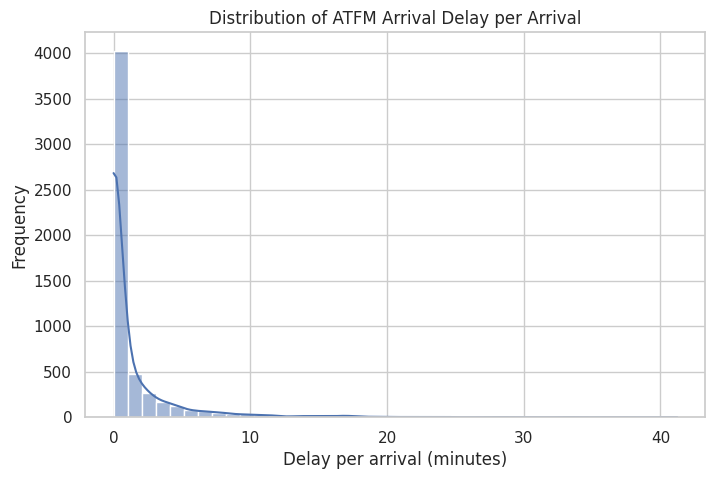

In [73]:
plt.figure(figsize=(8, 5))
sns.histplot(df["delay_per_arr"], bins=40, kde=True)
plt.title("Distribution of ATFM Arrival Delay per Arrival")
plt.xlabel("Delay per arrival (minutes)")
plt.ylabel("Frequency")
plt.show()

**Interpretation (Center / Spread / Shape / Normality / Outliers):**
In this histogram almost all the days are squished near zero. That tall bar (about 4000 days) means most of the time the airports have basically no delay per arrival, flights land on time.
The values stretch out to about 40 minutes, but after 5 minutes there's almost nothing, just a long thin tail. So the shape is clearly right-skewed: lots of calm days and only a few bad ones. It's not a normal distribution, which would look like a symmetric bell.
Those few points way out at 10, 20, even 40 minutes are the outliers we found with the z-score. They're rare but real, probably the bad-weather or congested days.
So the airports run smoothly most of the time, and the heavy delay days are the exception, which is exactly what our Phase 4 model will try to predict.

### 10.2 Count plot — records per airport (univariate, categorical)

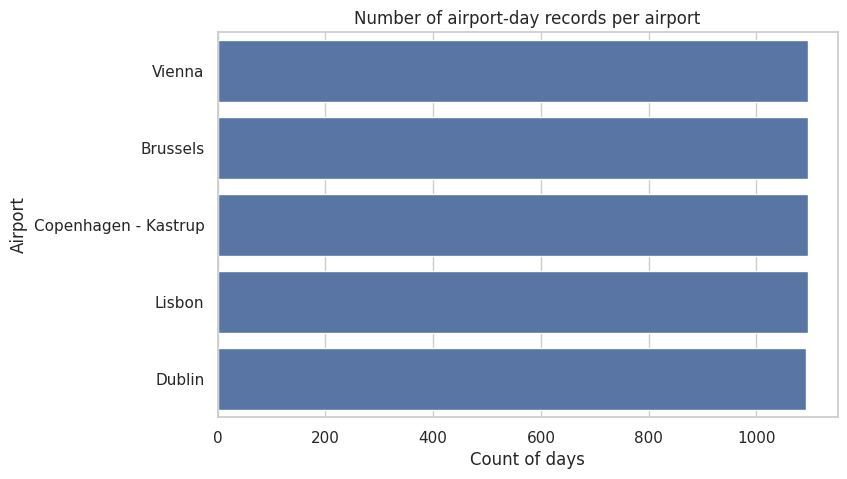

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="APT_NAME", order=df["APT_NAME"].value_counts().index)
plt.title("Number of airport-day records per airport")
plt.xlabel("Count of days")
plt.ylabel("Airport")
plt.show()

**Intrepretation:**
 the bars are equal across all five airports, each one has about the same number of days. This means the data is balanced and no airport is over represented, so it won't bias the plots or the model.

### 10.3 Box plot — `delay_per_arr` by airport (multivariate)

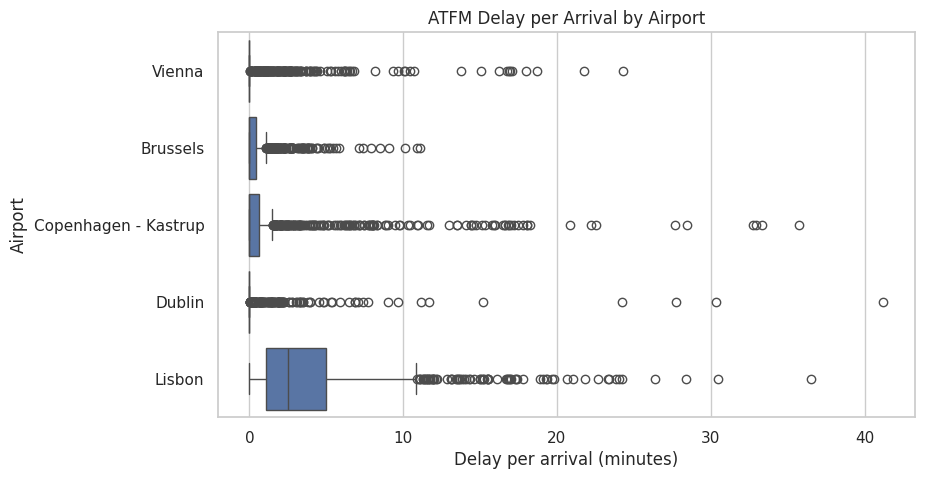

In [75]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="delay_per_arr", y="APT_NAME", orient="h")
plt.title("ATFM Delay per Arrival by Airport")
plt.xlabel("Delay per arrival (minutes)")
plt.ylabel("Airport")
plt.show()

**Interpretation:**
Interpretation: this box plot compares the delay per arrival across the five airports.
Lisbon clearly stands out, it has the biggest box and the highest median (around 3 minutes), so it has the worst and most variable punctuality of the group. The other four airports (Vienna, Brussels, Copenhagen, Dublin) all have tiny boxes sitting near zero, meaning most of their days have almost no delay.
Every airport has a long line of outlier dots stretching to the right, those are the rare bad days that go up to 20, 30, even 40 minutes. Copenhagen and Lisbon have the most outliers, so they get hit by congested days more often.
So overall Lisbon is the most delay-prone airport, while the others usually run smoothly with only occasional bad days. The box plot is useful here because it makes these differences and the outliers easy to spot.

### 10.4 Line plot — monthly mean delay over time (multivariate, time series)

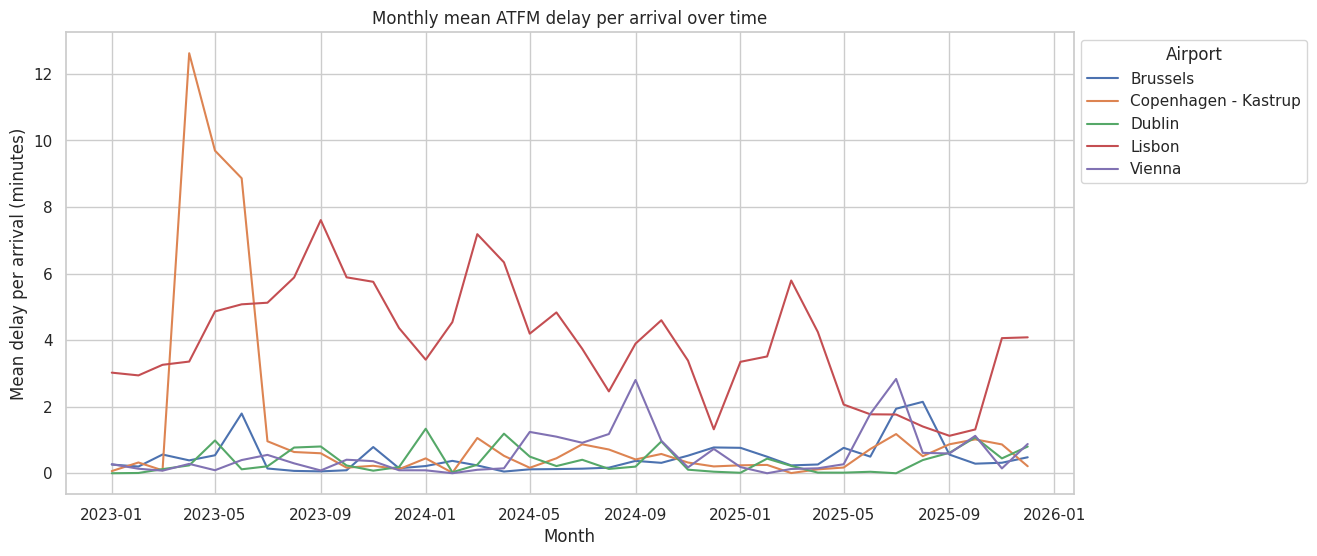

In [76]:
df["month_start"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby(["month_start", "APT_NAME"])["delay_per_arr"].mean().reset_index()

plt.figure(figsize=(13, 6))
sns.lineplot(data=monthly, x="month_start", y="delay_per_arr", hue="APT_NAME")
plt.title("Monthly mean ATFM delay per arrival over time")
plt.xlabel("Month")
plt.ylabel("Mean delay per arrival (minutes)")
plt.legend(title="Airport", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

### Interpretation

This line graph shows the **average monthly delay per arriving flight** from **2023 to 2025** for each airport.

The red line (Lisbon) records the highest average delays for most of the period, typically ranging between 3 and 7 minutes per arrival. It also shows a noticeable increase during the summer months, which is consistent with higher traffic volumes during the peak travel season.

The orange line displays a sharp spike in early 2023, reaching approximately 12 minutes per arrival, before falling and stabilizing at a much lower level. This spike may reflect an exceptional disruption such as severe weather, air traffic congestion, or industrial action.

The remaining airports maintain relatively low delay levels throughout the period, generally staying within the range of 0 to 2 minutes per arrival, with only minor fluctuations over time.

Overall, Lisbon consistently experiences the highest delay levels, while the other airports demonstrate better punctuality. The seasonal increases and occasional exceptional spikes suggest that both **airport characteristics** and **time of year** are important factors influencing delays and should therefore be considered in the Phase 4 predictive model.

### 10.5 Bar plot — mean delay by airport (multivariate, with 95% CI)

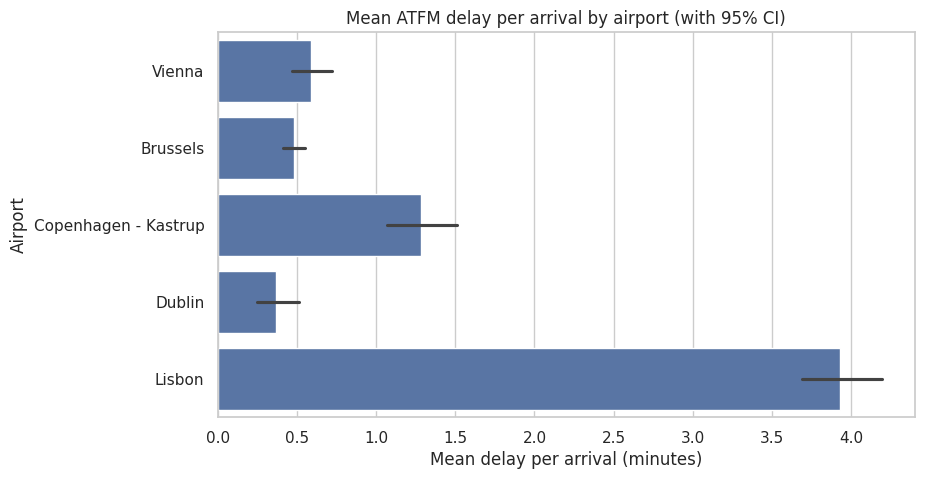

In [77]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="delay_per_arr", y="APT_NAME", orient="h")
plt.title("Mean ATFM delay per arrival by airport (with 95% CI)")
plt.xlabel("Mean delay per arrival (minutes)")
plt.ylabel("Airport")
plt.show()

intrepretation : this bar plot shows the average delay per arrival for each airport, with the black lines being the 95% confidence interval.
Lisbon is by far the worst at around 3.9 minutes, then Copenhagen at about 1.3, while Vienna, Brussels and Dublin are all low (~0.4–0.6 min), with Dublin the best. The confidence lines are small, so the averages are reliable. This matches the box plot and line plot, Lisbon clearly stands out as the most delay-prone airport.

### 10.6 Bar plot with `hue` — season × airport

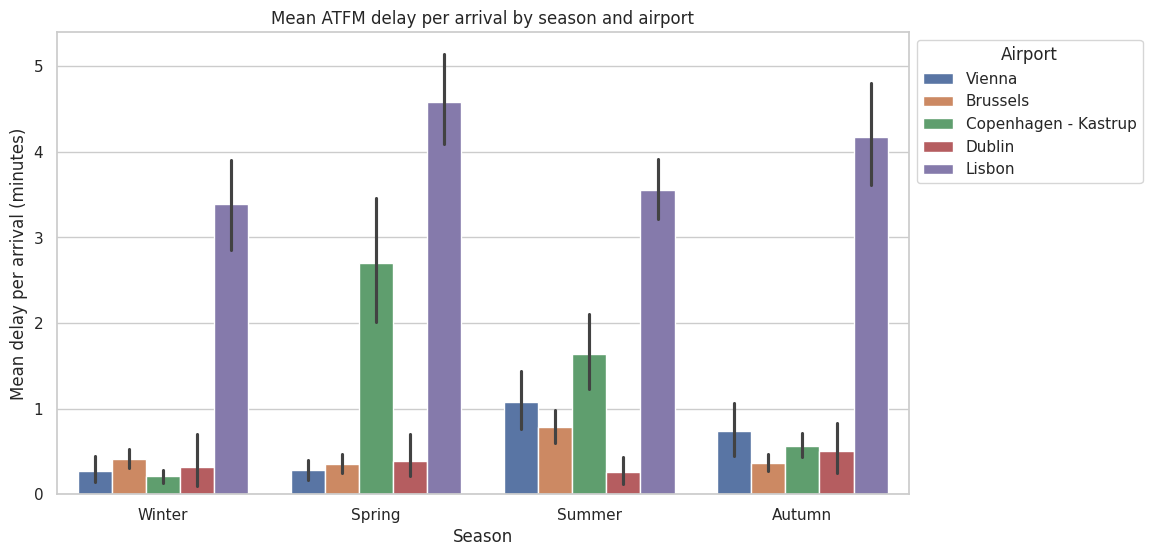

In [78]:
plt.figure(figsize=(11, 6))
sns.barplot(data=df, x="season", y="delay_per_arr", hue="APT_NAME",
            order=["Winter", "Spring", "Summer", "Autumn"])
plt.title("Mean ATFM delay per arrival by season and airport")
plt.xlabel("Season")
plt.ylabel("Mean delay per arrival (minutes)")
plt.legend(title="Airport", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

**Interpretation:**  

This grouped bar chart uses color-coded bars to compare the **average delay per arrival** across different **seasons** and **airports** simultaneously.

Lisbon Airport shows the highest average delays in every season, with particularly high values during spring and autumn, reaching approximately 4–4.5 minutes per arrival. This indicates that delays at Lisbon remain consistently elevated throughout the year.

Copenhagen Airport exhibits a noticeable seasonal pattern, with delays increasing significantly during spring and summer and reaching approximately 2.7 minutes per arrival. Delay levels are considerably lower during the remaining seasons.

Vienna and Brussels experience modest increases in delay during the summer months but generally maintain low delay levels throughout the year. Dublin shows the most stable performance, with relatively low delays across all seasons.

Overall, the chart suggests that seasonality affects airports differently. Lisbon experiences consistently high delays regardless of season, Copenhagen shows strong seasonal increases during spring and summer, and the remaining airports experience only minor seasonal variation. These findings indicate that both **airport location** and **time of year** influence delay patterns, making them valuable predictors for the Phase 4 model.

### 10.7 Scatter plot — daily arrivals vs delay (multivariate)

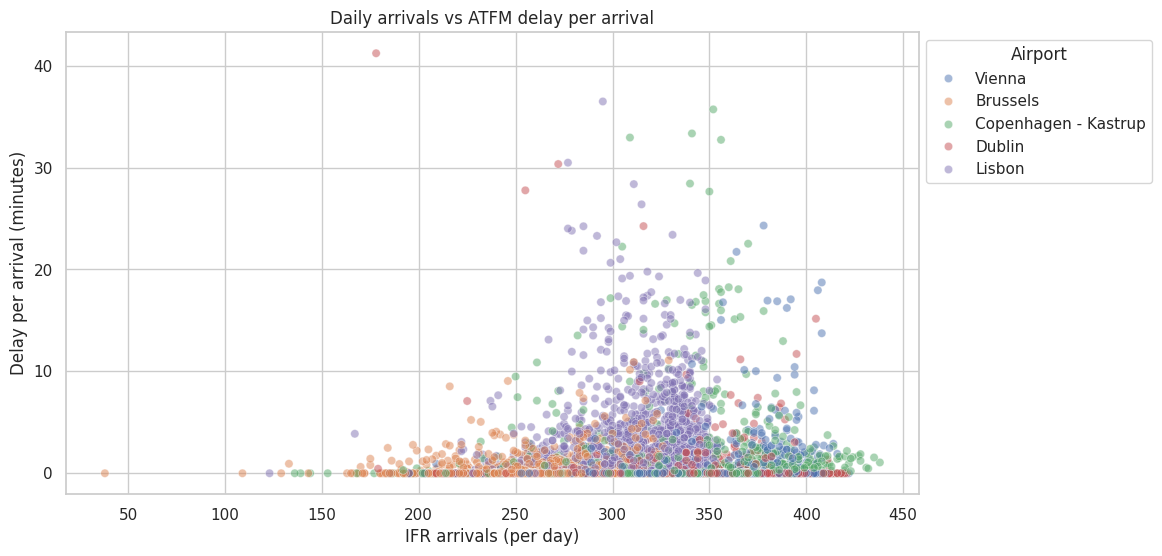

In [79]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x="FLT_ARR_1", y="delay_per_arr", hue="APT_NAME", alpha=0.5)
plt.title("Daily arrivals vs ATFM delay per arrival")
plt.xlabel("IFR arrivals (per day)")
plt.ylabel("Delay per arrival (minutes)")
plt.legend(title="Airport", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

### Interpretation

This scatter plot illustrates the relationship between **daily airport traffic** (measured by the number of arriving flights per day) and **delay per arrival**, with points colored by airport.

The graph suggests a weak positive relationship between traffic volume and delays. Higher delay values tend to occur more frequently on days with a larger number of arrivals, particularly when daily traffic exceeds approximately 250 flights. This indicates that busier days are generally associated with increased delays.

However, the relationship is not strong, as the majority of observations remain clustered near zero delay even at high traffic levels. This suggests that airports can often handle increased traffic without experiencing substantial delays.

Lisbon appears to have consistently higher delay values than the other airports, while Brussels maintains relatively low delays even during periods of heavier traffic. Several extreme observations are also visible, including days with delays of 30–40 minutes despite only moderate traffic levels. For example, one Dublin observation shows nearly 40 minutes of delay with approximately 180 arrivals, suggesting that factors other than traffic volume contributed to the disruption.

It is important to note that **correlation does not imply causation**. While traffic volume and delays are related, increased arrivals do not necessarily cause delays directly. External factors such as weather conditions, air traffic management restrictions, or operational disruptions may influence both variables simultaneously. Therefore, the observed relationship should be interpreted as an association rather than direct causation.

Overall, the plot indicates that traffic volume contributes to delay levels, but it is only one of several factors affecting airport performance and should be considered alongside other predictors in the Phase 4 model.

### 10.8 Correlation heatmap (multivariate)

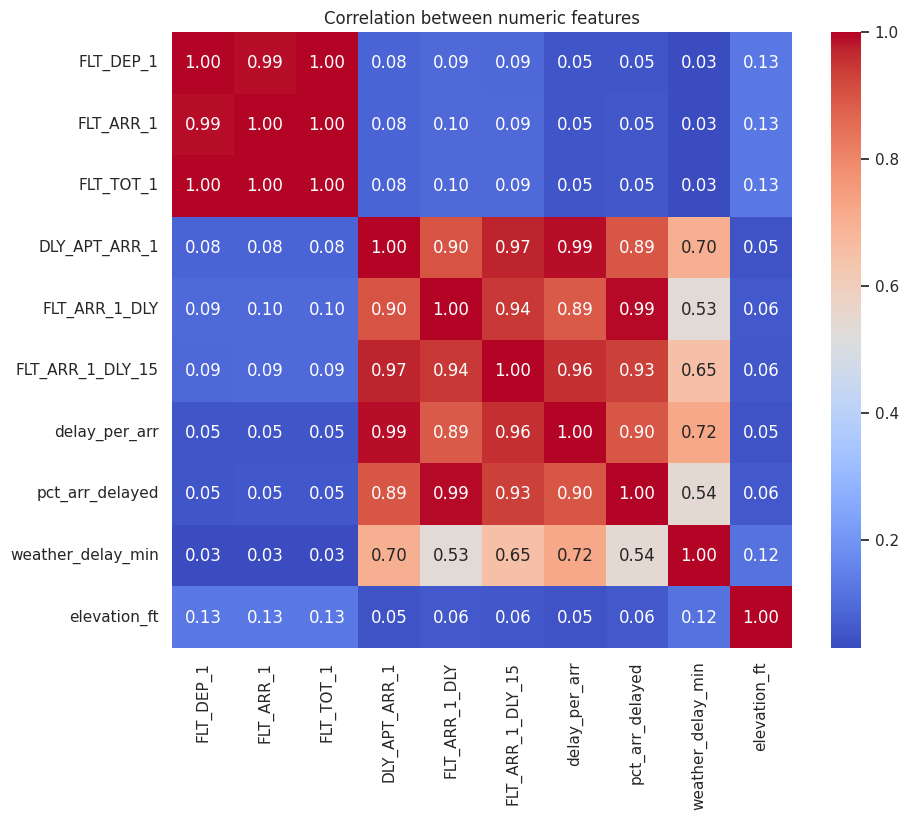

In [80]:
num_cols = ["FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1", "DLY_APT_ARR_1",
            "FLT_ARR_1_DLY", "FLT_ARR_1_DLY_15", "delay_per_arr",
            "pct_arr_delayed", "weather_delay_min", "elevation_ft"]
cor = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric features")
plt.show()

### Interpretation

This correlation heat map illustrates the relationships between the numerical variables in the dataset, where darker red colors indicate stronger positive correlations and lighter colors indicate weaker relationships.

Two clear clusters can be observed. The traffic-related variables (`FLT_DEP_1`, `FLT_ARR_1`, and `FLT_TOT_1`) are almost perfectly correlated, with correlation coefficients close to 0.99–1.00. This is expected because they all measure different aspects of airport traffic volume.

Similarly, the delay-related variables (`delay_per_arr`, `pct_arr_delayed`, and other delay metrics) exhibit strong positive correlations, typically ranging from 0.89 to 0.99. These variables capture different representations of airport delay performance and therefore tend to move together.

In contrast, the relationships between the traffic variables and the delay variables are relatively weak, with correlation values generally between 0.05 and 0.10. This suggests that traffic volume alone is not a strong predictor of delays, which is consistent with the findings from the scatter plot analysis.

The variable `weather_delay_min` shows a moderate positive correlation with delay measures (approximately 0.7), indicating that weather-related disruptions play an important role in explaining delay patterns.

By comparison, `elevation_ft` displays little to no correlation with the other variables, suggesting that airport elevation has minimal influence on traffic levels or delay performance within this dataset.

Overall, the heat map indicates that weather factors are more strongly associated with delays than traffic volume, while airport elevation appears to have little predictive value. These insights can help guide feature selection for the Phase 4 predictive model.

## 11. Save the processed dataset

We store the clean analytical dataset in `data/processed/` (per the required folder structure). The helper z-score column is dropped first.


In [81]:
import os
os.makedirs("data/processed", exist_ok=True)

df_final = df.drop(columns=["delay_z"])
df_final.to_csv("data/processed/flight_delay_analytical.csv", index=False)
print("Saved:", df_final.shape, "-> data/processed/flight_delay_analytical.csv")

Saved: (5477, 35) -> data/processed/flight_delay_analytical.csv


**italicized tex**tOn Google Colab**, to download the saved file to your computer (so you can commit it to GitHub), run:

```python
from google.colab import files
files.download("data/processed/flight_delay_analytical.csv")
```



In our final phase, we put together a clean and reproducible **airport-day** dataset that covers five European airports—specifically in Ireland, Denmark, Portugal, Belgium, and Austria. We achieved this by combining EUROCONTROL's airport traffic data and arrival ATFM delay information with metadata from OurAirports, all sourced from reliable, permanent URLs.

Once we cleaned the data (fixing data types, checking for inconsistencies, removing duplicates, and handling missing values) and engineered features (including date features, delay ratios, weather elements, and the `delay_level` target), we ended up with a dataset that meets our project requirements: **over 1,000 rows, more than 15 meaningful features, and data from 5 different countries.**

The visualizations reveal that ATFM arrival delays are **right-skewed**—most days are pretty calm, but a few can be quite severe. We also noticed differences **between airports** and variations by **season**, with weather playing a significant role. These trends, along with the correlation heatmap, suggest that traffic and weather-related features .